In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DIVYA\OneDrive\Desktop\letsgo\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
print( "Shape:",df.shape)
print("Class Distribution:",df['Class'].value_counts())

Shape: (284807, 31)
Class Distribution: Class
0    284315
1       492
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

#Separate feature and target
X = df.drop('Class', axis =1)
y = df['Class']

#Train-test split (80% train, 20% test)
X_train , X_test , y_train, y_test = train_test_split(
    X, y ,test_size =0.2, random_state=42, stratify =y
)


In [18]:
#Apply SMOTE on Training Data Only

from imblearn.over_sampling import SMOTE
#create the SMOTE object
sm = SMOTE(random_state=42)

#Apply only on training data
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [31]:
from collections import Counter

print("Class Distribution after SMOTE:")
print(Counter(y_train_resampled))

Class Distribution after SMOTE:
Counter({0: 227451, 1: 227451})


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

#build the model using input layer
model = models.Sequential()
model.add(layers.Input(shape=(X_train_resampled.shape[1],))) #replaces input_shape warning
model.add(layers.Dense(10, activation ='relu'))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

#compile the model
model.compile(optimizer='adam',
              loss = 'binary_crossentropy',
              metrics=['accuracy'])

#train the model
history = model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs = 10,
    batch_size = 32,
    validation_split =0.2
)

Epoch 1/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.8545 - loss: 6.8212 - val_accuracy: 0.9016 - val_loss: 3.6559
Epoch 2/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9297 - loss: 3.0961 - val_accuracy: 0.8706 - val_loss: 8.8347
Epoch 3/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9431 - loss: 2.5154 - val_accuracy: 0.9855 - val_loss: 0.2056
Epoch 4/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9493 - loss: 2.0793 - val_accuracy: 0.9364 - val_loss: 2.2302
Epoch 5/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.9541 - loss: 1.7038 - val_accuracy: 0.9892 - val_loss: 0.1143
Epoch 6/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.9569 - loss: 1.3584 - val_accuracy: 0.8998 - val_loss: 4.5247
Epoch 7/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9592 - loss: 1.0401 - val_accuracy: 0.8715 - val_loss: 6.2362
Epoch 8/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 

In [34]:
#get predicted probabilities for test set
y_pred_prob = model.predict(X_test)

#connect probabilities to binary predictions(0 /1)
y_pred = (y_pred_prob > 0.5).astype("int32")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 957us/step


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

cr = classification_report(y_test, y_pred)
print("Classification Report:\n", cr)

Confusion Matrix:
 [[56492   372]
 [   12    86]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.19      0.88      0.31        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.65     56962
weighted avg       1.00      0.99      1.00     56962



 PR-AUC Score 0.7429880703597946


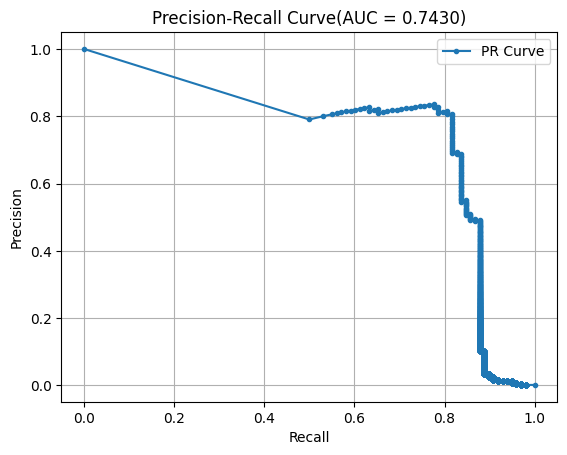

In [38]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

#get precision, recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

#calculate PR AUC curve
pr_auc = auc(recall, precision)
print(" PR-AUC Score", pr_auc)

#plot the precision-recall curve
plt.plot(recall, precision, marker='.', label ='PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve(AUC = {pr_auc:.4f})')
plt.legend()
plt.grid(True)
plt.show()